# Lesson 3: Linear Regression — From Scratch & With scikit-learn

**Goal:** Understand *mathematically* how a linear regression model finds its weight `w` and bias `b`.

We'll predict **exam score** from **hours studied**, and compute `w` and `b` three ways:

1. By hand, using the **closed-form formula** (the actual math).
2. Using **scikit-learn** (and confirm we get the same numbers).
3. Visualize the best-fit line.

> Upload this notebook to [Google Colab](https://colab.research.google.com) and run each cell top to bottom.

## Step 0: The data

`X` = hours studied (feature), `y` = exam score (label).

In [5]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y = np.array([35, 42, 50, 90, 62, 68, 78, 85], dtype=float)

print('Hours (X):', X)
print('Score (y):', y)

Hours (X): [1. 2. 3. 4. 5. 6. 7. 8.]
Score (y): [35. 42. 50. 90. 62. 68. 78. 85.]


## Step 1: The closed-form formula (the math)

For a single feature, the best-fit line `y = w*x + b` that minimizes Mean Squared Error has an *exact* solution:

$$ w = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} \qquad b = \bar{y} - w\,\bar{x} $$

where $\bar{x}$ and $\bar{y}$ are the means of x and y.

**Plain English:** `w` = (how x and y move together) divided by (how much x spreads out). `b` then just shifts the line so it passes through the average point.

In [6]:
x_mean = X.mean()
y_mean = y.mean()

numerator = np.sum((X - x_mean) * (y - y_mean))   # how x and y vary together
denominator = np.sum((X - x_mean) ** 2)            # how much x varies

w = numerator / denominator
b = y_mean - w * x_mean

print(f'x_mean = {x_mean}')
print(f'y_mean = {y_mean}')
print(f'numerator   (sum of (x-x_mean)(y-y_mean)) = {numerator}')
print(f'denominator (sum of (x-x_mean)^2)         = {denominator}')
print()
print(f'w (slope)     = {w:.4f}')
print(f'b (intercept) = {b:.4f}')

x_mean = 4.5
y_mean = 63.75
numerator   (sum of (x-x_mean)(y-y_mean)) = 278.0
denominator (sum of (x-x_mean)^2)         = 42.0

w (slope)     = 6.6190
b (intercept) = 33.9643


## Step 2: Confirm with scikit-learn

Same `.fit()` / `.predict()` pattern you'll use everywhere. The numbers should match Step 1 exactly.

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X.reshape(-1, 1), y)   # sklearn wants X as a 2D array

print(f'sklearn w = {model.coef_[0]:.4f}')
print(f'sklearn b = {model.intercept_:.4f}')

pred_12 = model.predict([[12]])[0]
print(f'Predicted score for 12 hours = {pred_12:.1f}')

sklearn w = 6.6190
sklearn b = 33.9643
Predicted score for 12 hours = 113.4


## Step 3: Visualize the best-fit line

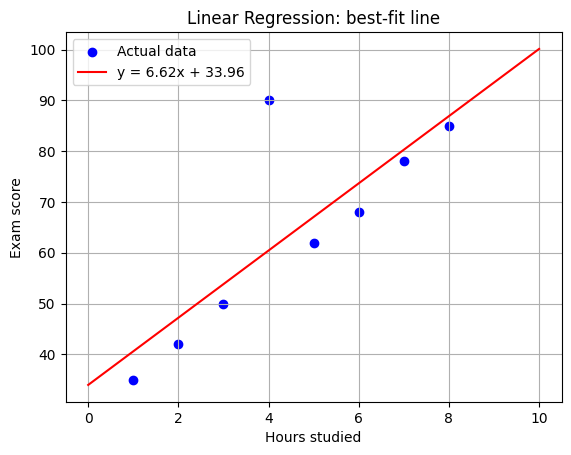

In [8]:
plt.scatter(X, y, color='blue', label='Actual data')
line_x = np.linspace(0, 10, 100)
line_y = w * line_x + b
plt.plot(line_x, line_y, color='red', label=f'y = {w:.2f}x + {b:.2f}')
plt.xlabel('Hours studied')
plt.ylabel('Exam score')
plt.title('Linear Regression: best-fit line')
plt.legend()
plt.grid(True)
plt.show()

## Your turn (experiments)

1. Change a `y` value to something weird (e.g. make the 4th score `90`). Re-run. Watch how `w` and `b` shift.
2. Add more data points to `X` and `y` and see how the line adjusts.
3. Predict the score for 12 hours. Does the answer still make sense? (Hint: this is *extrapolation* — we'll discuss its dangers later.)